1. 주제 선정
 - 커피: 카페인 함량 당도 등을 고려해 맞춤형 추천
 - 호텔: 포털사이트에 있는 리뷰 등을 수집해 추천
 - 교통사고 분석: 공공데이터포털에서 데이터 수집 용이
 - 도서: 알라딘 등의 온라인 서점에서 리뷰 등을 수집.
 
 -> 데이터 수집이 용이한 '도서 추천'으로 결정

 2. 데이터 수집
 - 알라딘에서 각 15개 장르의 상위 200권, 총 3000권의 베스트셀러에 대한 리뷰와 가격 등을 수집.
 
 3. 컨셉 설정
 - 입력창에 도서 취향에 따른 도서 추천하는 챗봇 스타일.
 - 질문을 임베딩하여 기본 책 정보를 조회
 - 메타데이터에 가격이나 장르를 조건을 추가

 4. 상세 구상
 - 데이터 정제 및 통합 (중복 제거, Missing Value 처리, HTML 제거)
 - 메타데이터 추출 및 키워드/토큰화 (장르, 가격, 리뷰 키워드)
 - 본문/소개 텍스트 Chunking (Chunk Size = 200)
 - 데이터 벡터화(Embedding) & Vector DB 구축

In [55]:
import pandas as pd
import numpy as np
from pprint import pprint

df = pd.read_json('output/aladin_bestsellers/all_bestsellers.json')
df.info()
df.isna().sum()
df.isna().any(axis=1).sum()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype                    
---  ------                --------------  -----                    
 0   title                 3000 non-null   str                      
 1   link                  3000 non-null   str                      
 2   author                3000 non-null   str                      
 3   pubDate               3000 non-null   str                      
 4   description           3000 non-null   str                      
 5   isbn                  3000 non-null   str                      
 6   isbn13                3000 non-null   str                      
 7   itemId                3000 non-null   int64                    
 8   priceSales            3000 non-null   int64                    
 9   priceStandard         3000 non-null   int64                    
 10  mallType              3000 non-null   str                      
 11  st

np.int64(1911)

In [56]:
df.isna().sum()
null_counts = df.isnull().sum() 
print(null_counts[null_counts > 0]) # 1911은 시리즈 권수에 따른 결측치
# 결측치가 하나라도 있는 행의 인덱스(행 이름) 추출
null_indices = df[df.isnull().any(axis=1)].title
# 인덱스 전체 출력 (List 형태로 보기)
pprint(list(null_indices))

seriesInfo    1911
dtype: int64
['머도쿠 - 두뇌를 자극하는 추리 퍼즐 80',
 '마음이 단단해지는 하루 한 문장 일본어 필사',
 '식단 짜주는 남자 밥피티 다이어트 레시피 - 맛있게 먹고 스트레스 없이 살 빼는 현실적인 식단 관리',
 '아픈 사람의 99%는 장누수다',
 '착한 염증 나쁜 염증 - 면역 , 질병 , 노화를 좌우하는 우리 몸의 조용한 지배자',
 '토지 필사 노트',
 '무진기행 필사북 - 이동진 평론가 추천! 무진기행, 서울 1964년 겨울, 역사, 건',
 '뇌가 멈추기 전에 - 서울대학교병원 뇌신경학자의 뇌졸중을 피하고 건강하게 오래 사는 법',
 '백년운동 - 척추.관절 아프지 않게 100세까지 운동하는 방법',
 '내 몸을 바꾸는 집밥테라피 - 뱃살과 혈당, 대사 이상을 개선하는 가장 확실한 방법',
 '파크골프 표준교재 - 전2권',
 '나는 알코올중독 의사였습니다',
 '당신은 사건 현장에 있습니다 1~3 스페셜 에디션 세트 - 전3권',
 '초역 부처의 말 필사집 - 2500년 동안 사랑받은',
 '필사, 어른이 되는 시간 - 소란한 세상에서 평온함을 찾는 가장 고귀한 방법',
 '쉽게 살찌는 사람, 쉽게 빠지는 사람 - 소금물 · 버터 · 고기만 제대로 먹어도 몸이 변한다',
 '만성질환 자연치료 식이요법 갭스 (GAPS diet)',
 '비만록 : 나는 마운자로를 맞는 의사다',
 '콩팥 대회복 - 고혈압, 당뇨, 동맥경화, 심장병 잡는 100년 콩팥 만들기',
 '미네랄은 어떻게 내 몸을 고치는가 - 에너지·수면·노화와 염증까지, 몸의 회복 스위치를 켜는 미네랄 혁명',
 '취미는 수학 - 어려워 보이지만 기분 좋게 풀리는 도형 퍼즐',
 '살찌지 않는 몸 - 평생 가볍게 살아가는 4주 대사 회복 프로젝트',
 '몸이 마음을 만든다 - 무기력 시대, 몸과 마음의 역량을 높이는 회복의 과학',
 '중국어 명대사 필사집 - 작품의 감동을 명대사로, 명대사 필사로 중국어 공부를',
 '내 몸 오래 

In [57]:
# 출력할 최대 행 수 제한 해제 (None으로 설정)
pd.set_option("display.max_rows", None)

# 전체 행 인덱스 출력
print(df.columns)
len(df.columns)

Index(['title', 'link', 'author', 'pubDate', 'description', 'isbn', 'isbn13',
       'itemId', 'priceSales', 'priceStandard', 'mallType', 'stockStatus',
       'mileage', 'cover', 'categoryId', 'categoryName', 'publisher',
       'salesPoint', 'adult', 'fixedPrice', 'customerReviewRank', 'bestRank',
       'seriesInfo', 'subInfo', 'category_name', 'category_id',
       'rank_in_category', 'api_isbn', 'publisherDescription',
       'fullDescription', 'reviewList', 'communityReviews', 'fetched_at',
       'bestSellerRank'],
      dtype='str')


34

In [58]:
df['customerReviewRank'].mean()
df['customerReviewRank'].quantile()
df['customerReviewRank'].median()


np.float64(10.0)

In [59]:
print(df['subInfo'])

0       {}
1       {}
2       {}
3       {}
4       {}
5       {}
6       {}
7       {}
8       {}
9       {}
10      {}
11      {}
12      {}
13      {}
14      {}
15      {}
16      {}
17      {}
18      {}
19      {}
20      {}
21      {}
22      {}
23      {}
24      {}
25      {}
26      {}
27      {}
28      {}
29      {}
30      {}
31      {}
32      {}
33      {}
34      {}
35      {}
36      {}
37      {}
38      {}
39      {}
40      {}
41      {}
42      {}
43      {}
44      {}
45      {}
46      {}
47      {}
48      {}
49      {}
50      {}
51      {}
52      {}
53      {}
54      {}
55      {}
56      {}
57      {}
58      {}
59      {}
60      {}
61      {}
62      {}
63      {}
64      {}
65      {}
66      {}
67      {}
68      {}
69      {}
70      {}
71      {}
72      {}
73      {}
74      {}
75      {}
76      {}
77      {}
78      {}
79      {}
80      {}
81      {}
82      {}
83      {}
84      {}
85      {}
86      {}
87      {}
88      {}
89      {}
90      {}

In [60]:
print(df['reviewList'])

0       []
1       []
2       []
3       []
4       []
5       []
6       []
7       []
8       []
9       []
10      []
11      []
12      []
13      []
14      []
15      []
16      []
17      []
18      []
19      []
20      []
21      []
22      []
23      []
24      []
25      []
26      []
27      []
28      []
29      []
30      []
31      []
32      []
33      []
34      []
35      []
36      []
37      []
38      []
39      []
40      []
41      []
42      []
43      []
44      []
45      []
46      []
47      []
48      []
49      []
50      []
51      []
52      []
53      []
54      []
55      []
56      []
57      []
58      []
59      []
60      []
61      []
62      []
63      []
64      []
65      []
66      []
67      []
68      []
69      []
70      []
71      []
72      []
73      []
74      []
75      []
76      []
77      []
78      []
79      []
80      []
81      []
82      []
83      []
84      []
85      []
86      []
87      []
88      []
89      []
90      []

In [61]:
# publisherDescription과 fullDescription 유사도 비교
from difflib import SequenceMatcher

def calculate_string_similarity(text1: str, text2: str) -> float:
    if not text1 or not text2:
        return 0.0
    
    # 두 문자열 간의 유사도 비율 계산
    return SequenceMatcher(None, str(text1), str(text2)).ratio()

# 사용 예시 (80% 이상 유사할 때 True)
score = calculate_string_similarity(df['publisherDescription'][0], df['fullDescription'][0])
print(f"문자열 유사도: {score:.2f}")

문자열 유사도: 1.00


In [62]:
# bestRank bestSellerRank 유사도 비교
from difflib import SequenceMatcher

def calculate_string_similarity(text1: str, text2: str) -> float:
    if not text1 or not text2:
        return 0.0
    
    # 두 문자열 간의 유사도 비율 계산
    return SequenceMatcher(None, str(text1), str(text2)).ratio()

# 사용 예시 (80% 이상 유사할 때 True)
score = calculate_string_similarity(df['bestRank'][0], df['bestSellerRank'][0])
print(f"문자열 유사도: {score:.2f}")

문자열 유사도: 1.00


필요한 컬럼

1. 'title': 책 제목 O
2. 'link': 구매링크 O
3. 'author': 작가 O
4. 'pubDate': 출판일 O
5. 'description': 책 상세설명 O
7. 'isbn13': 국제표준도서번호 13자리. 신형. 메타데이터로 활용하면 추천이나 검색 정확도 제고에 도움될 것으로 기대됨 O
8. 'itemId': 알라딘 내에서 사용하는 도서인식번호. 알라딘의 구매링크와 연결된다면 메타데이터로 가치가 있음. O
9. 'priceSales': 할인가 O 
10. 'priceStandard': 정가 
14. 'cover': 책 표지 이미지 O
16. 'categoryName': 추천 결과에 카테고리이름을 보여줌으로써 이용자에게 원하는 도서가 맞다는 것을 확인시켜주는 역할 O
17. 'publisher': 출판사 O
18. 'adult': 성인도서 여부 표시 O
26. 'rank_in_category': 카테고리 내의 순위 O 
27. 'api_isbn': API 호출 및 외부 데이터 연결 O,
29. 'fullDescription': 도서에 대한 상세한 설명 O
31. 'communityReviews': 독자 반응. 임베딩 필요 O
32. 'fetched_at': 리뷰 작성일자 O

불필요한 컬럼

6. 'isbn': 국제표준도서번호 10자리.구형. isbn13으로도 호환 가능함. X
11. 'mallType': 모든 행에서 값이 BOOK으로 지워도 무방함. X
12. 'stockStatus': 품절 유무를 확인하는 행. 도서구매 프로세스가 아니라 추천이므로 지워도 됨 X
11. 'mallType': 모든 행에서 값이 BOOK으로 지워도 무방함. X
13. 'mileage': 가격의 일정비율에 따라 쌓이는 마일리지로 도서 추천과는 무관 X
18. 'salesPoint': 알라딘 내부의 산출식에 따라 도출된 추천점수. 산출근거 확인 불가 X
19. 'fixedPrice': 정가. 할인 전 가격. PriceStandard와 동일함 X
20. 'customerReviewRank': 소비자(독자) 평점. 평균이 8.201, 상위 25%가 10.0, 중앙값이 10.0으로 과하게 높은 곳에 있어 평점을 근거로 추천순위를 정하는 것은 무의미함 X
23. 'subInfo': {}. 빈 딕셔너리 X 
24. 'category_name': categoryId와 중복됨 X
28. 'publisherDescription': fullDescription과 유사도 1.00으로 완전일치 X 
30. 'reviewList': [] 빈 리스트 X



판단 유보

15. 'categoryId': (CamelCase) 알라딘 Open API의 원본 Response 키 값. 카테고리 찾을 때 필요할듯. 메타데이터로 활용 가능할지도. 
25. 'category_id': category_id (snake_case): API 응답을 받아 처리하는 파이썬 내부 코드, DB schema 또는 로컬 저장용 파일(categories.json, Dataframe/CSV) 등에서 파이썬 관례(PEP 8)에 맞게 변환하여 사용하는 필드명. 
----> categoryId와 category_id 중에서 어떤 걸 사용할지 정해야 함. 둘 다 사용하면 에러가 발생할 우려가 있음.
21. 'bestRank': 전체 베스트셀러의 순위. 각 카테고리.json에서는 해당 카테고리 내에서의 순위. 어떤 책이 잘 팔렸는지 판단하는 지표가 될 수는 있으나, '도서 추천'에는 유용하지 않음.
33. 'bestSellerRank': 파이프라인 내 변수명 정리 단계나 특정 API 응답 필드에서 단순화하여 사용하는 베스트셀러 순위 필드명. bestRank와 유사도 1.00으로 완전일치. 단, API 검색과 챗봇 설계에 유리할 수 있으므로 판단 유보
22. 'seriesInfo': 해당 도서가 시리즈일 경우 설명하는 컬럼. 시리즈만 모아서 통계를 낼 때 유용함.


텍스트 임베딩

기초 통계 분석

In [63]:
# all_bestseller에서 카테고리별 비중. 막대그래프, 최빈값
# all_bestseller에서 가격 평균, 중앙값, 편차 등.
# all_bestseller에서 출판시기와 순위 관련 통계. 산점도.
# 각 카테고리 별 가격 평균, 중앙값. 
# 각 카테고리 별 가격 평균, 중앙값을 구하고 각각 비교하는 막대그래프.
# 여행.json에서 여행지역 막대그래프
# 역사.json에서 한국사, 세계사(서양사/동양사)로 나누는 막대그래프 
# 요리_살림.json에서 요리와 살림으로 나누어 비중을 비교하는 막대그래프.
# 인문학.json에서 각 분야를 더 나누어 분류하는 막대그래프
# 컴퓨터_모바엘.json에서 인공지능 관련 도서의 비율을 알아보고 어떤 인공지능에 관한 것인지 보여주는 막대그래프


## 통합 전처리 파이프라인
`all_bestsellers.json`을 기준으로 ISBN13/Item ID 중복을 통합하고, 추천에 필요한 컬럼만 남기기.

In [64]:
import json, re, html
from pathlib import Path
import pandas as pd

DATA_DIR = Path('output/aladin_bestsellers')
raw = json.loads((DATA_DIR / 'all_bestsellers.json').read_text(encoding='utf-8'))
raw_df = pd.DataFrame(raw)
raw_df.shape


(3000, 34)

### 정제 규칙
- `itemId`를 우선 키로 사용하고, 없으면 `isbn13`을 키로 사용.
- 동일 도서의 장르는 리스트로 병합.
- 가격·출판일·저자가 없거나 유효하지 않은 레코드는 제거.
- 소개·리뷰는 결측을 빈 문자열로 바꾸고 검색 텍스트에서 제외.

In [65]:
REQUIRED = ["title", "author", "pubDate", "priceSales", "priceStandard", "isbn13", "itemId", "category_name", "description", "fullDescription", "publisherDescription", "communityReviews", "reviewList", "link", "cover"]

# 문자열 정제, 공백 처리, html 제거
def clean_text(value):
    if value is None or (isinstance(value, float) and pd.isna(value)): return ""
    if isinstance(value, (list, dict)): value = " ".join(map(str, value))
    text = html.unescape(str(value))
    text = re.sub(r"<[^>]*>", " ", text)
    return re.sub(r"\s+", " ", text).strip()

# clean_text 함수를 이용해 정제
df = raw_df.reindex(columns=REQUIRED).copy()
for col in ["title", "author", "description", "fullDescription", "publisherDescription", "reviewList", "communityReviews"]:
    df[col] = df[col].map(clean_text)
df[col].head(5)

0    {'itemId': 296236093, 'paperId': 14016308, 'ra...
1    {'itemId': 395486703, 'paperId': 17342053, 'ra...
2    {'itemId': 397217574, 'paperId': 17400196, 'ra...
3    {'itemId': 95733788, 'paperId': 11497937, 'rat...
4    {'itemId': 399803229, 'paperId': 17442023, 'ra...
Name: communityReviews, dtype: str

In [66]:
# 데이터 타입 변환 및 표준화
df["priceSales"] = pd.to_numeric(df["priceSales"], errors="coerce")
df["priceStandard"] = pd.to_numeric(df["priceStandard"], errors="coerce")
df["pubDate"] = pd.to_datetime(df["pubDate"], errors="coerce")
df["dedup_key"] = df["itemId"].fillna("").astype(str).where(lambda s: s.ne(""), df["isbn13"].fillna("").astype(str))
before = len(df)

# 중복 제거용 식별키
df = df[df["dedup_key"].ne("") & df["title"].ne("") & df["author"].ne("") & df["pubDate"].notna() & df["priceSales"].notna()].copy()
# 장르목록 정제 및 set을 통한 중복 제거
def merge_genres(values):
    return sorted({clean_text(v) for v in values if clean_text(v)})

# 대표 행은 첫 행으로 두고, 장르만 모두 보존
clean_df = df.groupby("dedup_key", sort=False, as_index=False).agg({**{c:"first" for c in df.columns if c not in ["dedup_key", "category_name"]}, "category_name": merge_genres})
clean_df["search_text"] = clean_df[["title", "author", "description", "fullDescription", "publisherDescription", "reviewList", "communityReviews"]].apply(lambda r: " ".join(x for x in r if x), axis=1)
clean_df = clean_df.drop(columns=["dedup_key"])
print(f"원본 {before:,}건 → 필수값 검증 후 {len(df):,}건 → 중복 제거 후 {len(clean_df):,}건")
clean_df.head(5)


원본 3,000건 → 필수값 검증 후 3,000건 → 중복 제거 후 2,558건


,title,author,pubDate,priceSales,priceStandard,isbn13,itemId,description,fullDescription,publisherDescription,communityReviews,reviewList,link,cover,category_name,search_text
0,당신은 사건 현장에 있습니다 - 일러스트 한 장으로 즐기는 추리 게임,"모데스토 가르시아 (지은이), 하비 데 카스트로 (그림), 엄지영 (옮긴이)",2022-05-30,25200,28000,9788927812975,296236093,"공항, 크루즈, 박물관, 경찰서 등 유럽 곳곳에서 의문의 사건이 발생했다. 뭔가 미...","유럽 전역에서 선풍적인 인기를 끌었던 신개념 추리게임북, 드디어 한국 상륙! 사건 ...","유럽 전역에서 선풍적인 인기를 끌었던 신개념 추리게임북, 드디어 한국 상륙! 사건 ...","{'itemId': 296236093, 'paperId': 14016308, 'ra...",,https://www.aladin.co.kr/shop/wproduct.aspx?It...,https://image.aladin.co.kr/product/29623/60/co...,[건강/취미],당신은 사건 현장에 있습니다 - 일러스트 한 장으로 즐기는 추리 게임 모데스토 가르...
1,머도쿠 - 두뇌를 자극하는 추리 퍼즐 80,"마누엘 가란드 (지은이), 박나림 (옮긴이)",2026-06-18,20700,23000,9788927813644,395486703,"""한 문제만 더."" 《머도쿠》는 이 짧은 말이 가장 잘 어울리는 추리 퍼즐북이다. ...","국내 출간 전 텀블벅 약 6,000% 달성! 한 문제만 풀려다 밤새 사건을 해결하게...","국내 출간 전 텀블벅 약 6,000% 달성! 한 문제만 풀려다 밤새 사건을 해결하게...","{'itemId': 395486703, 'paperId': 17342053, 'ra...",,https://www.aladin.co.kr/shop/wproduct.aspx?It...,https://image.aladin.co.kr/product/39548/67/co...,[건강/취미],"머도쿠 - 두뇌를 자극하는 추리 퍼즐 80 마누엘 가란드 (지은이), 박나림 (옮긴..."
2,마음이 단단해지는 하루 한 문장 일본어 필사,안은미 (지은이),2026-07-16,19800,22000,9791166572296,397217574,"일본의 대표 예술가 제아미, 문제적 천재 다자이 오사무, 일본 근대 문학의 아버지 ...",매일 아침 일본어 명문장 한 줄을 손으로 옮겨 쓰는 것만으로 마음에 단단한 힘이 생...,매일 아침 일본어 명문장 한 줄을 손으로 옮겨 쓰는 것만으로 마음에 단단한 힘이 생...,"{'itemId': 397217574, 'paperId': 17400196, 'ra...",,https://www.aladin.co.kr/shop/wproduct.aspx?It...,https://image.aladin.co.kr/product/39721/75/co...,"[건강/취미, 인문학]",마음이 단단해지는 하루 한 문장 일본어 필사 안은미 (지은이) 일본의 대표 예술가 ...
3,크툴루의 부름 : 수호자 룰북,"샌디 피터슨, 린 윌리스, 마이크 메이슨, 폴 프리커 (지은이), 박나림 (옮긴이)",2016-11-02,34200,38000,9788988060391,95733788,크툴루의 부름은 H.P. 러브크래프트의 세계를 다루는 테이블 롤플레잉 게임이다. 크...,"죽지 않은 것은 영원히 누울 수 있고, 기이한 억겁 속에서는 죽음마저 죽을 수 있다...","죽지 않은 것은 영원히 누울 수 있고, 기이한 억겁 속에서는 죽음마저 죽을 수 있다...","{'itemId': 95733788, 'paperId': 11497937, 'rat...",,https://www.aladin.co.kr/shop/wproduct.aspx?It...,https://image.aladin.co.kr/product/9573/37/cov...,[건강/취미],"크툴루의 부름 : 수호자 룰북 샌디 피터슨, 린 윌리스, 마이크 메이슨, 폴 프리커..."
4,식단 짜주는 남자 밥피티 다이어트 레시피 - 맛있게 먹고 스트레스 없이 살 빼는 현...,밥피티 (지은이),2026-08-05,20700,23000,9791124656051,399803229,80만 회원님의 식단을 책임지고 있는 밥피티의 첫 다이어트 레시피북. 일대일 온라인...,"80만 인플루언서 밥피티와 함께, 먹어도 되는 똑똑한 다이어트 ① 맛있고 든든한데 ...","80만 인플루언서 밥피티와 함께, 먹어도 되는 똑똑한 다이어트 ① 맛있고 든든한데 ...","{'itemId': 399803229, 'paperId': 17442023, 'ra...",,https://www.aladin.co.kr/shop/wproduct.aspx?It...,https://image.aladin.co.kr/product/39980/32/co...,"[건강/취미, 요리/살림]",식단 짜주는 남자 밥피티 다이어트 레시피 - 맛있게 먹고 스트레스 없이 살 빼는 현...


In [67]:
# 파일시스템에 csv 형태로 저장
OUT = DATA_DIR / "cleaned_books.csv"
save_df = clean_df.copy()
save_df["category_name"] = save_df["category_name"].map(json.dumps, ensure_ascii=False)
save_df.to_csv(OUT, index=False, encoding="utf-8-sig")
print(f"저장 완료: {OUT} / {len(save_df):,}건")


저장 완료: output\aladin_bestsellers\cleaned_books.csv / 2,558건


In [68]:
## 전처리 과정별 감소 원인 진단
# 아래 셀은 원본 3,000건이 각 단계에서 몇 건씩 제외되었는지 보여줍니다.
diagnosis = raw_df.reindex(columns=REQUIRED).copy()
diagnosis["priceSales_num"] = pd.to_numeric(diagnosis["priceSales"], errors="coerce")
diagnosis["pubDate_date"] = pd.to_datetime(diagnosis["pubDate"], errors="coerce")
diagnosis["item_key"] = diagnosis["itemId"].fillna("").astype(str).replace("nan", "")
diagnosis["isbn_key"] = diagnosis["isbn13"].fillna("").astype(str).replace("nan", "")
diagnosis["dedup_key_diag"] = diagnosis["item_key"].where(diagnosis["item_key"].ne(""), diagnosis["isbn_key"])

diagnostic_rows = []
def add_step(name, mask):
    diagnostic_rows.append({"제외 단계": name, "제외 건수": int((~mask).sum()), "통과 건수": int(mask.sum())})

valid_title = diagnosis["title"].map(clean_text).ne("")
valid_author = diagnosis["author"].map(clean_text).ne("")
valid_date = diagnosis["pubDate_date"].notna()
valid_price = diagnosis["priceSales_num"].notna()
valid_key = diagnosis["dedup_key_diag"].ne("")
add_step("원본 데이터", pd.Series(True, index=diagnosis.index))
add_step("제목 결측/빈 문자열", valid_title)
add_step("저자 결측/빈 문자열", valid_title & valid_author)
add_step("출판일 결측 또는 잘못된 형식", valid_title & valid_author & valid_date)
add_step("판매가격 결측 또는 숫자 변환 실패", valid_title & valid_author & valid_date & valid_price)
add_step("Item ID와 ISBN13 모두 누락", valid_title & valid_author & valid_date & valid_price & valid_key)

valid_mask = valid_title & valid_author & valid_date & valid_price & valid_key
valid_keys = diagnosis.loc[valid_mask, "dedup_key_diag"]
duplicate_count = int(valid_keys.duplicated(keep="first").sum())
diagnostic = pd.DataFrame(diagnostic_rows)
diagnostic.loc[len(diagnostic)] = ["중복 도서 제거(Item ID/ISBN13)", duplicate_count, int(valid_mask.sum()) - duplicate_count]
diagnostic["누적 제외 건수"] = diagnostic["제외 건수"].cumsum()
display(diagnostic)
print(f"최종 결과: {len(clean_df):,}건 / 원본: {len(raw_df):,}건 / 총 감소: {len(raw_df)-len(clean_df):,}건")


,제외 단계,제외 건수,통과 건수,누적 제외 건수
0,원본 데이터,0,3000,0
1,제목 결측/빈 문자열,0,3000,0
2,저자 결측/빈 문자열,0,3000,0
3,출판일 결측 또는 잘못된 형식,0,3000,0
4,판매가격 결측 또는 숫자 변환 실패,0,3000,0
5,Item ID와 ISBN13 모두 누락,0,3000,0
6,중복 도서 제거(Item ID/ISBN13),442,2558,442


최종 결과: 2,558건 / 원본: 3,000건 / 총 감소: 442건


기초통계분석

In [69]:
# all_bestseller에서 카테고리별 비중. 막대그래프, 최빈값
# all_bestseller에서 가격 평균, 중앙값, 편차 등.
# all_bestseller에서 출판시기와 순위 관련 통계. 산점도.
# 각 카테고리 별 가격 평균, 중앙값. 
# 각 카테고리 별 가격 평균, 중앙값을 구하고 각각 비교하는 막대그래프.
# 여행.json에서 여행지역 막대그래프
# 역사.json에서 한국사, 세계사(서양사/동양사)로 나누는 막대그래프 
# 요리_살림.json에서 요리와 살림으로 나누어 비중을 비교하는 막대그래프.
# 인문학.json에서 각 분야를 더 나누어 분류하는 막대그래프
# 컴퓨터_모바엘.json에서 인공지능 관련 도서의 비율을 알아보고 어떤 인공지능에 관한 것인지 보여주는 막대그래프


In [70]:
## 베스트셀러 통계 및 세부 카테고리 분석
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rcParams

# Windows 한글 폰트 설정
font_candidates = ["Malgun Gothic", "맑은 고딕", "NanumGothic"]
installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
font_name = next((f for f in font_candidates if f in installed_fonts), None)
if font_name:
    rcParams["font.family"] = font_name
rcParams["axes.unicode_minus"] = False

eda = raw_df.copy()
eda["priceSales_num"] = pd.to_numeric(eda["priceSales"], errors="coerce")
eda["rank_num"] = pd.to_numeric(eda["bestSellerRank"].fillna(eda["bestRank"]), errors="coerce")
eda["pubDate_date"] = pd.to_datetime(eda["pubDate"], errors="coerce")
eda["pubYear"] = eda["pubDate_date"].dt.year
sns.set_theme(style="whitegrid", rc={"axes.unicode_minus": False})


In [71]:
def plot_counts(series, title, xlabel):
    counts = series.dropna().astype(str).value_counts()
    counts.plot.bar(figsize=(12, 5), color="#5470C6")
    plt.title(title); plt.xlabel(xlabel); plt.ylabel("도서 수")
    plt.xticks(rotation=35, ha="right", fontsize=9); plt.tick_params(axis="both", labelsize=9); plt.tight_layout(pad=1.5); plt.show()
    return counts


In [73]:
# all_bestseller에서 가격 평균, 중앙값, 편차 등.
price_stats = eda["priceSales_num"].describe()[["count", "mean", "50%", "std", "min", "max"]].rename({"50%":"median"})
display(price_stats.to_frame("판매가"))

,판매가
count,3000.000000
mean,19306.716667
median,17820.000000
std,9861.064090
min,2690.000000
max,298000.000000


C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\3960970995.py:4: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) Arial.
  plt.gca().invert_yaxis(); plt.title("출판연도와 베스트셀러 순위"); plt.tight_layout(); plt.show()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\3960970995.py:4: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from font(s) Arial.
  plt.gca().invert_yaxis(); plt.title("출판연도와 베스트셀러 순위"); plt.tight_layout(); plt.show()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\3960970995.py:4: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) Arial.
  plt.gca().invert_yaxis(); plt.title("출판연도와 베스트셀러 순위"); plt.tight_layout(); plt.show()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\3960970995.py:4: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  plt.gca().invert_yaxis(); plt.title("출판연도와 베스트셀러 순위"); plt.tight_layout(); plt.show()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812

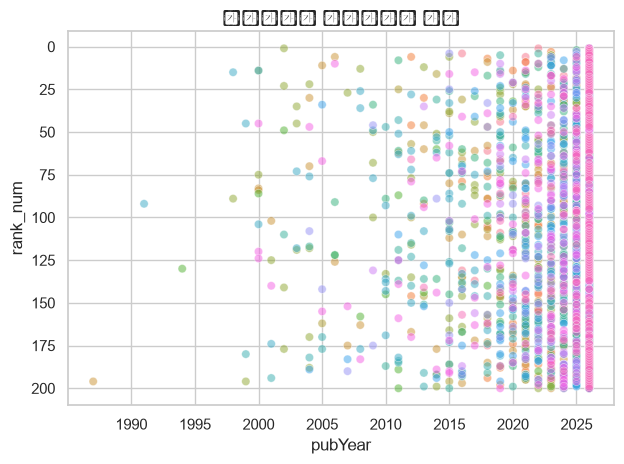

In [74]:
# all_bestseller에서 출판시기와 순위 관련 통계. 산점도.
scatter_df = eda.dropna(subset=["pubYear", "rank_num"])
sns.scatterplot(data=scatter_df, x="pubYear", y="rank_num", hue="category_name", alpha=.5, legend=False)
plt.gca().invert_yaxis(); plt.title("출판연도와 베스트셀러 순위"); plt.tight_layout(); plt.show()
# 출판연도가 최근인 베스트셀러의 수가 많으며, 최근일수록 rank_num의 값이 높았음.

,mean,median
category_name,,
역사,24615.25,20700.0
컴퓨터/모바일,22820.10,21600.0
예술/대중문화,22478.50,18900.0
과학,20713.60,19800.0
경제경영,20631.85,19800.0
사회과학,20311.90,18000.0
요리/살림,20232.00,19800.0
인문학,19579.80,17820.0
건강/취미,19578.90,18000.0


C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\1208248219.py:5: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from font(s) Arial.
  plt.title("카테고리별 판매가 평균과 중앙값"); plt.ylabel("가격(원)"); plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\1208248219.py:5: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) Arial.
  plt.title("카테고리별 판매가 평균과 중앙값"); plt.ylabel("가격(원)"); plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\1208248219.py:5: UserWarning: Glyph 52980 (\N{HANGUL SYLLABLE KEOM}) missing from font(s) Arial.
  plt.title("카테고리별 판매가 평균과 중앙값"); plt.ylabel("가격(원)"); plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\1208248219.py:5: UserWarning: Glyph 54504 (\N{HANGUL SYLLABLE PYU}) missing from font(s) Arial.
  plt.title("카테고리별 판매가 평균과 중앙값"); 

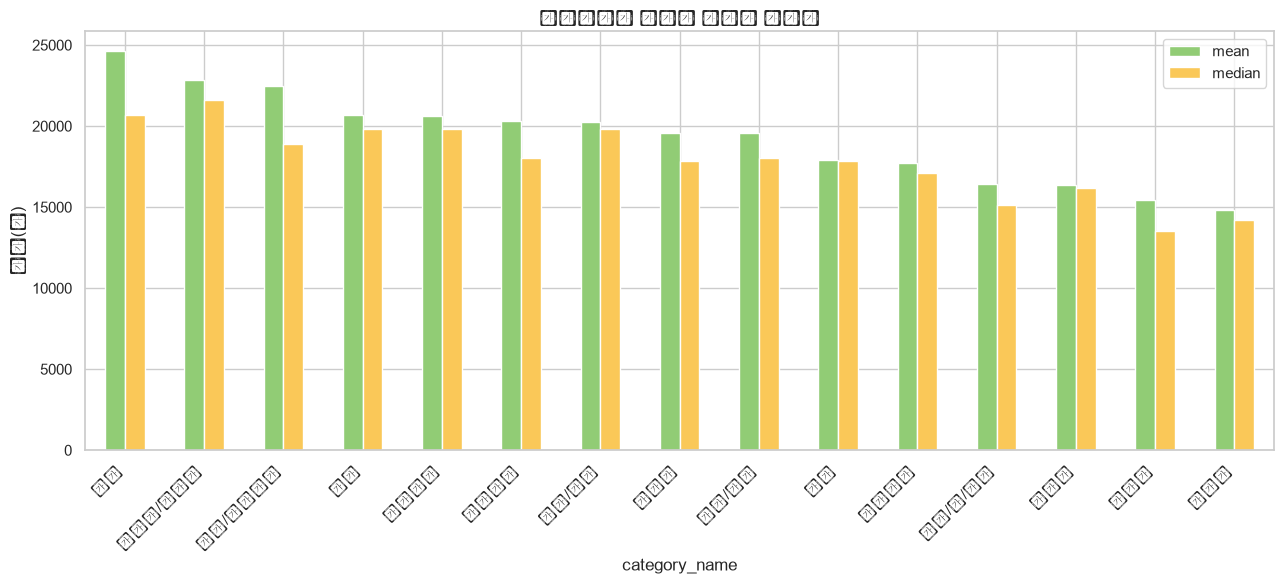

In [75]:
# 각 카테고리 별 가격 평균, 중앙값. 
category_price = eda.groupby("category_name")["priceSales_num"].agg(["mean", "median"]).sort_values("mean", ascending=False)
display(category_price)
category_price.plot.bar(figsize=(13, 6), color=["#91CC75", "#FAC858"])
plt.title("카테고리별 판매가 평균과 중앙값"); plt.ylabel("가격(원)"); plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

In [76]:

def load_category(filename):
    return pd.DataFrame(json.loads((DATA_DIR / filename).read_text(encoding="utf-8")))

def text_of(frame):
    return (frame["title"].fillna("") + " " + frame["description"].fillna("")).map(clean_text)


C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\1925643083.py:5: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) Arial.
  plt.xticks(rotation=35, ha="right", fontsize=9); plt.tick_params(axis="both", labelsize=9); plt.tight_layout(pad=1.5); plt.show()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\1925643083.py:5: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from font(s) Arial.
  plt.xticks(rotation=35, ha="right", fontsize=9); plt.tick_params(axis="both", labelsize=9); plt.tight_layout(pad=1.5); plt.show()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\1925643083.py:5: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  plt.xticks(rotation=35, ha="right", fontsize=9); plt.tick_params(axis="both", labelsize=9); plt.tight_layout(pad=1.5); plt.show()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\1925643083.py:5: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) Arial.
  plt.xti

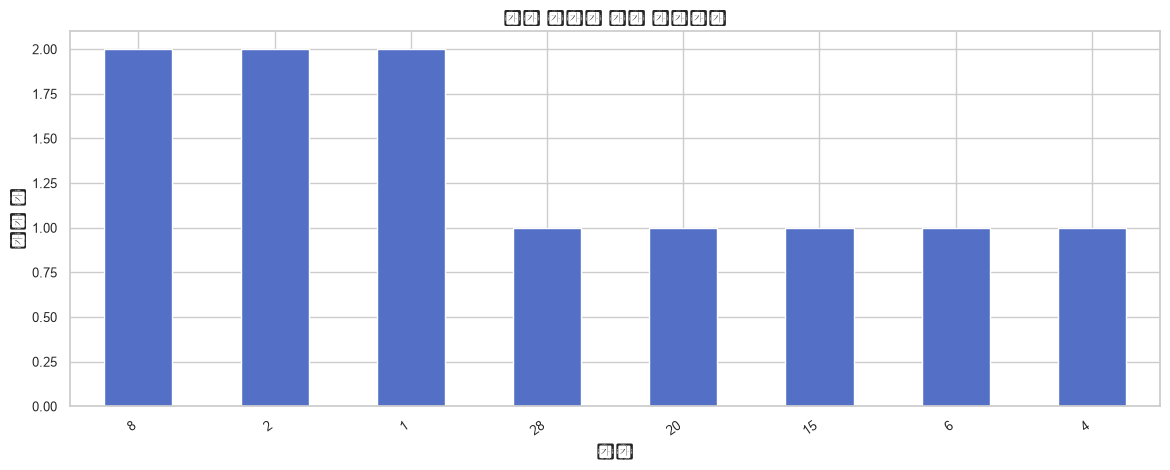

8     2
2     2
1     2
28    1
20    1
15    1
6     1
4     1
Name: count, dtype: int64

In [77]:
# 여행.json에서 여행지역 막대그래프
travel = load_category("여행.json"); travel_text = text_of(travel)
regions = ["국내", "서울", "제주", "부산", "일본", "중국", "유럽", "미국", "동남아", "호주", "대만", "베트남", "태국"]
travel_counts = pd.Series({x: travel_text.str.contains(x, regex=False).sum() for x in regions}).sort_values(ascending=False)
plot_counts(travel_counts[travel_counts.gt(0)], "여행 도서의 주요 여행지역", "지역")

C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\1925643083.py:5: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) Arial.
  plt.xticks(rotation=35, ha="right", fontsize=9); plt.tick_params(axis="both", labelsize=9); plt.tight_layout(pad=1.5); plt.show()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\1925643083.py:5: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) Arial.
  plt.xticks(rotation=35, ha="right", fontsize=9); plt.tick_params(axis="both", labelsize=9); plt.tight_layout(pad=1.5); plt.show()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\1925643083.py:5: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) Arial.
  plt.xticks(rotation=35, ha="right", fontsize=9); plt.tick_params(axis="both", labelsize=9); plt.tight_layout(pad=1.5); plt.show()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\1925643083.py:5: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) Arial.
  plt.xtic

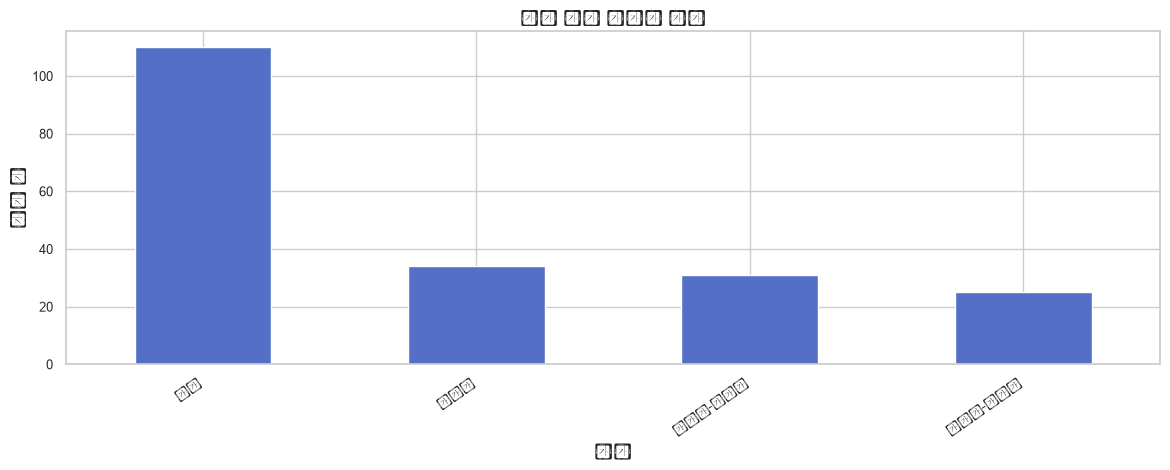

기타         110
한국사         34
세계사-서양사     31
세계사-동양사     25
Name: count, dtype: int64

In [78]:
# 역사.json에서 한국사, 세계사(서양사/동양사)로 나누는 막대그래프 
history = load_category("역사.json"); history_text = text_of(history)
history_type = pd.Series("기타", index=history.index)
history_type[history_text.str.contains("한국사|조선|고려|삼국|대한민국", regex=True)] = "한국사"
history_type[history_text.str.contains("유럽|서양|미국|영국|프랑스|독일|로마", regex=True)] = "세계사-서양사"
history_type[history_text.str.contains("동양|중국|일본|아시아|인도", regex=True)] = "세계사-동양사"
plot_counts(history_type, "역사 도서 분야별 비중", "분야")


C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\1925643083.py:5: UserWarning: Glyph 49332 (\N{HANGUL SYLLABLE SAL}) missing from font(s) Arial.
  plt.xticks(rotation=35, ha="right", fontsize=9); plt.tick_params(axis="both", labelsize=9); plt.tight_layout(pad=1.5); plt.show()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\1925643083.py:5: UserWarning: Glyph 47548 (\N{HANGUL SYLLABLE RIM}) missing from font(s) Arial.
  plt.xticks(rotation=35, ha="right", fontsize=9); plt.tick_params(axis="both", labelsize=9); plt.tight_layout(pad=1.5); plt.show()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\1925643083.py:5: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) Arial.
  plt.xticks(rotation=35, ha="right", fontsize=9); plt.tick_params(axis="both", labelsize=9); plt.tight_layout(pad=1.5); plt.show()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\1925643083.py:5: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) Arial.
  plt.xtic

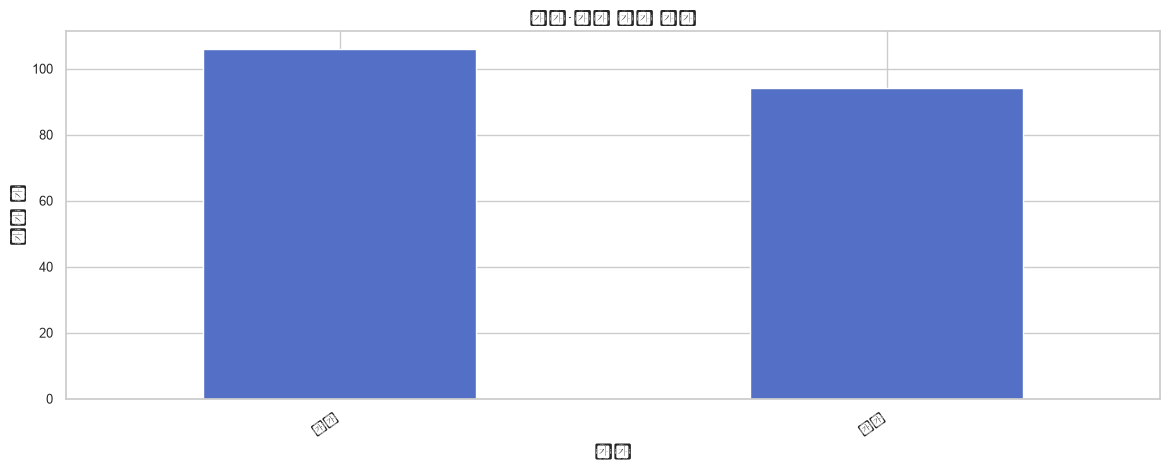

살림    106
요리     94
Name: count, dtype: int64

In [79]:
# 요리_살림.json에서 요리와 살림으로 나누어 비중을 비교하는 막대그래프.
cooking = load_category("요리_살림.json"); cooking_text = text_of(cooking)
cooking_type = cooking_text.str.contains("요리|레시피|베이킹|제과|제빵|쿠킹", regex=True).map({True:"요리", False:"살림"})
plot_counts(cooking_type, "요리·살림 도서 비중", "분야")

C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\1925643083.py:5: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) Arial.
  plt.xticks(rotation=35, ha="right", fontsize=9); plt.tick_params(axis="both", labelsize=9); plt.tight_layout(pad=1.5); plt.show()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\1925643083.py:5: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) Arial.
  plt.xticks(rotation=35, ha="right", fontsize=9); plt.tick_params(axis="both", labelsize=9); plt.tight_layout(pad=1.5); plt.show()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\1925643083.py:5: UserWarning: Glyph 50616 (\N{HANGUL SYLLABLE EON}) missing from font(s) Arial.
  plt.xticks(rotation=35, ha="right", fontsize=9); plt.tick_params(axis="both", labelsize=9); plt.tight_layout(pad=1.5); plt.show()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\1925643083.py:5: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) Arial.
  plt.xtick

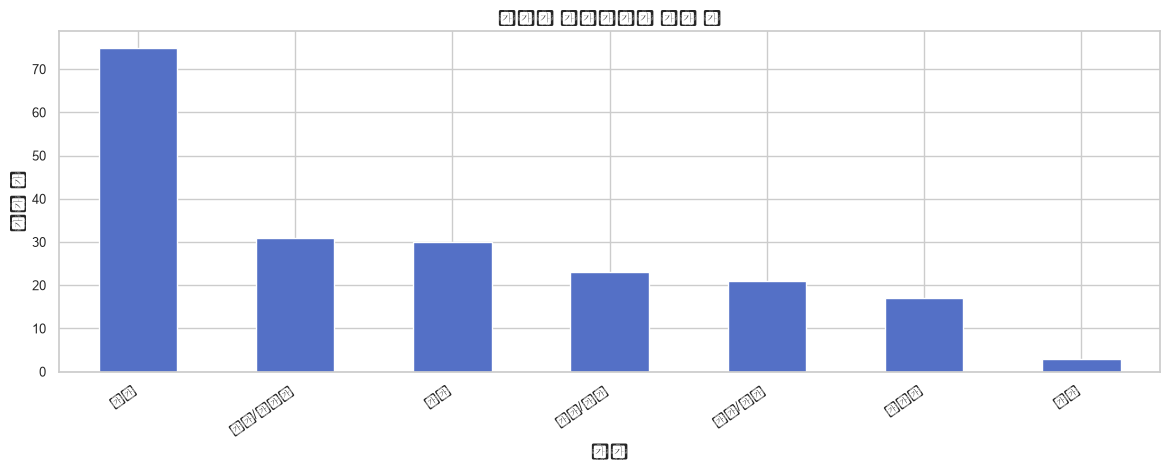

기타        75
언어/언어학    31
철학        30
고전/문학     23
문화/예술     21
심리학       17
종교         3
Name: count, dtype: int64

In [80]:
# 인문학.json에서 각 분야를 더 나누어 분류하는 막대그래프
humanities = load_category("인문학.json"); human_text = text_of(humanities)
human_patterns = {"철학":"철학|사상|윤리", "심리학":"심리|정신분석|인지", "종교":"종교|신학|불교|기독교", "고전/문학":"고전|문학", "언어/언어학":"언어|문법|번역", "문화/예술":"문화|예술|미학"}
human_type = pd.Series("기타", index=humanities.index)
for label, pattern in human_patterns.items(): human_type[human_text.str.contains(pattern, regex=True)] = label
plot_counts(human_type, "인문학 세부분야별 도서 수", "분야")

C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\1925643083.py:5: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) Arial.
  plt.xticks(rotation=35, ha="right", fontsize=9); plt.tick_params(axis="both", labelsize=9); plt.tight_layout(pad=1.5); plt.show()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\1925643083.py:5: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) Arial.
  plt.xticks(rotation=35, ha="right", fontsize=9); plt.tick_params(axis="both", labelsize=9); plt.tight_layout(pad=1.5); plt.show()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\1925643083.py:5: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  plt.xticks(rotation=35, ha="right", fontsize=9); plt.tick_params(axis="both", labelsize=9); plt.tight_layout(pad=1.5); plt.show()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_10812\1925643083.py:5: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) Arial.
  plt.xtick

AI 관련 도서: 142권 / 전체 200권 (71.00%)


C:\Users\Playdata\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Playdata\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Playdata\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Playdata\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Playdata\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGU

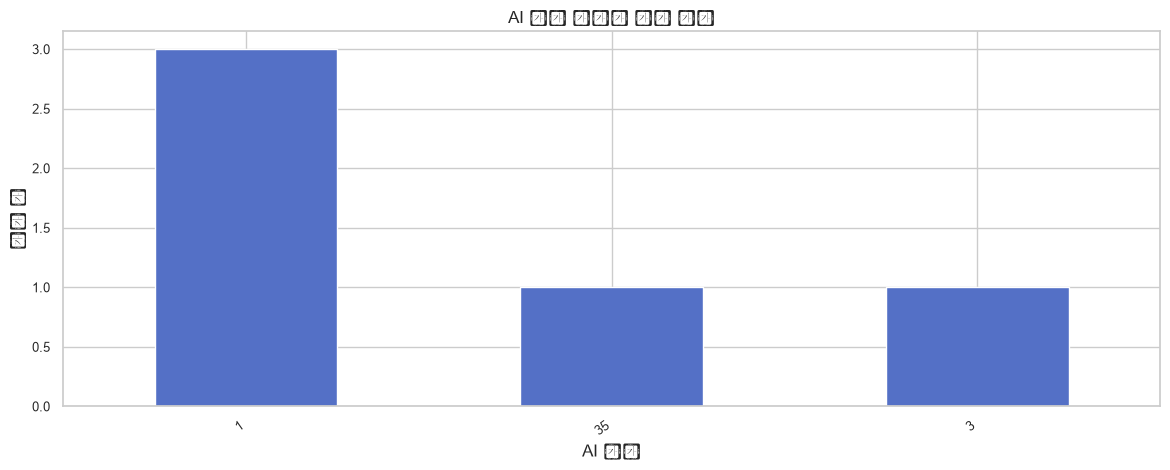

,title,description
0,챗GPT·제미나이·클로드까지 모두를 위한 AI - ChatGPT부터 Google G...,"가장 대중적인 ChatGPT와 구글 제미나이를 활용한 효과적인 질문 작성법은 물론,..."
1,박태웅의 AI 강의 2026 - 인공지능 진화의 가속화부터 AI 기본사회와 일자리의...,"챗GPT 등장 이후 AI는 운영체제이자 파트너, 휴머노이드로 확장되며 삶과 산업을 ..."
2,"바로바로 클로드 with 코워크, 스킬, 클로드 코드, 디자인 - 인공지능, 에이전...",
3,클로드 코드 제대로 시작하기 - 최신 클로드 코드 완벽 반영! 바이브 코딩부터 숏폼...,
4,클로드 에이전트 협업의 기술 - 클로드 코워크와 코드로 구축하는 멀티 에이전트 시스템,"비주얼 환경인 클로드 코워크부터 터미널 환경인 클로드 코드까지, MCP 연동과 서브..."
5,혼자 공부하는 바이브 코딩 with 클로드 코드 - AI와 1:1 대화하며 배우는 ...,"코딩을 잘 모르는 독자도 대화하듯 만들고, 질문을 통해 앱을 개선하며 AI 시대의 ..."
6,"AI, 신의 탄생 인간의 종말 - 초지능의 탄생, 그 이후 벌어질 일들",
7,기계가 언어를 사용한다는 것에 대한 인문학적 사유 - LLM 인공지능이 생성하는 글...,언어는 지금까지 인간만이 유일무이하게 소유한 것이라고 여겨왔다. 그런데 AI 기술이...
8,AI 에이전트 주식 자동 매매 - 얄코와 함께 코딩 없이 만드는 나만의 주식 자동 ...,주식 자동 매매 프로그램을 만들고 싶지만 코딩이 두렵다면 이 책이 해답이다. 커서 ...
11,"유튜브에서 음원 발매까지 AI 플레이리스트 with 수노, 제미나이, 리퍼, 캔바,...","수노, 유디오 등 AI 음원 생성 도구의 등장으로 음악을 전혀 모르는 사람도 취향을..."


In [81]:
# 컴퓨터_모바엘.json에서 인공지능 관련 도서의 비율을 알아보고 어떤 인공지능에 관한 것인지 보여주는 막대그래프
computer = load_category("컴퓨터_모바일.json"); computer_text = text_of(computer)
ai_mask = computer_text.str.contains("인공지능|AI|머신러닝|딥러닝|생성형|ChatGPT|챗GPT|GPT", case=False, regex=True)
print(f"AI 관련 도서: {ai_mask.sum():,}권 / 전체 {len(computer):,}권 ({ai_mask.mean()*100:.2f}%)")
ai_patterns = {"생성형 AI/GPT":"생성형|ChatGPT|챗GPT|GPT", "머신러닝":"머신러닝|machine learning", "딥러닝":"딥러닝|deep learning", "컴퓨터 비전":"컴퓨터 비전|이미지 인식", "자연어 처리":"자연어 처리|NLP|언어 모델"}
ai_counts = pd.Series({label: computer_text[ai_mask].str.contains(pattern, case=False, regex=True).sum() for label, pattern in ai_patterns.items()})
plot_counts(ai_counts[ai_counts.gt(0)], "AI 관련 도서의 세부 주제", "AI 주제")
display(computer.loc[ai_mask, ["title", "description"]].head(20))


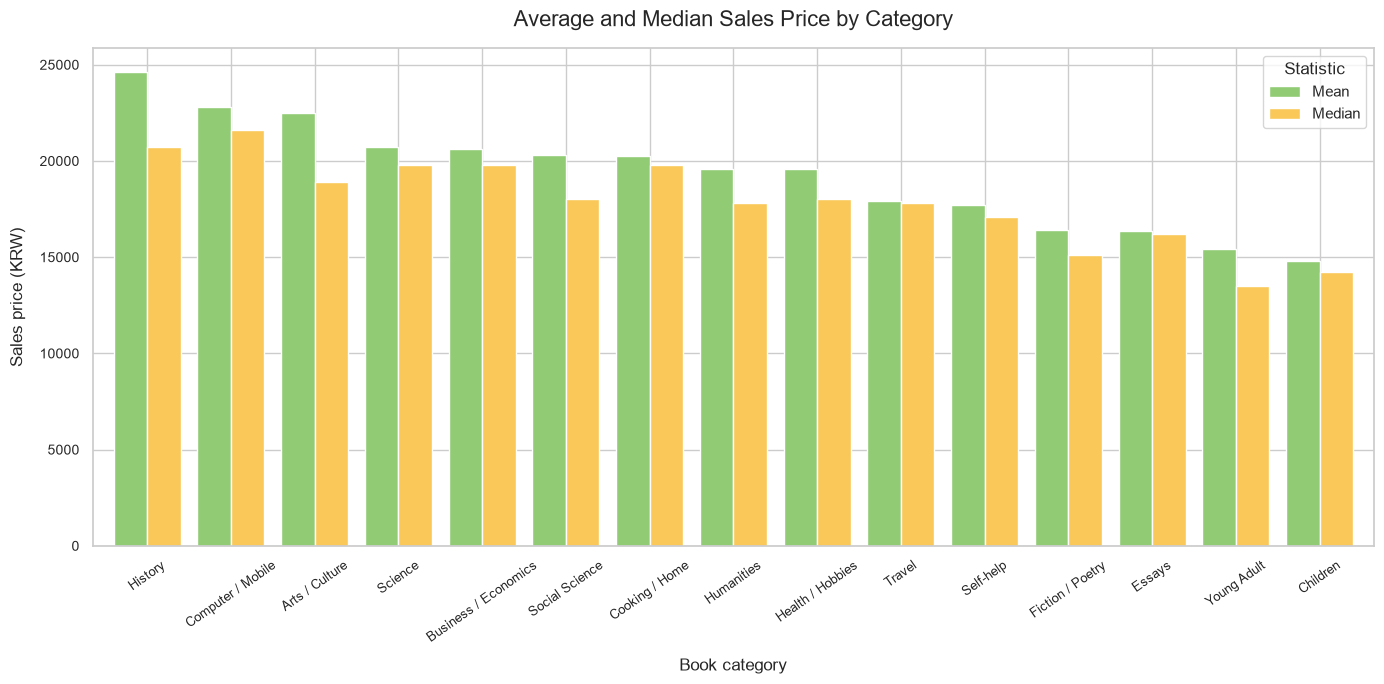

In [82]:
## Category price comparison (font-safe version)
category_labels = {"소설/시/희곡":"Fiction / Poetry", "경제경영":"Business / Economics", "자기계발":"Self-help", "인문학":"Humanities", "사회과학":"Social Science", "역사":"History", "과학":"Science", "에세이":"Essays", "예술/대중문화":"Arts / Culture", "여행":"Travel", "요리/살림":"Cooking / Home", "건강/취미":"Health / Hobbies", "어린이":"Children", "청소년":"Young Adult", "컴퓨터/모바일":"Computer / Mobile"}
safe_price = category_price.copy()
safe_price.index = [category_labels.get(str(x), str(x)) for x in safe_price.index]
ax = safe_price.plot.bar(figsize=(14, 7), color=["#91CC75", "#FAC858"], width=.8)
ax.set_title("Average and Median Sales Price by Category", fontsize=16, pad=16)
ax.set_xlabel("Book category", fontsize=12, labelpad=10)
ax.set_ylabel("Sales price (KRW)", fontsize=12, labelpad=10)
ax.legend(["Mean", "Median"], title="Statistic", loc="upper right")
ax.tick_params(axis="x", labelrotation=35, labelsize=9)
ax.tick_params(axis="y", labelsize=10)
plt.tight_layout()
plt.show()


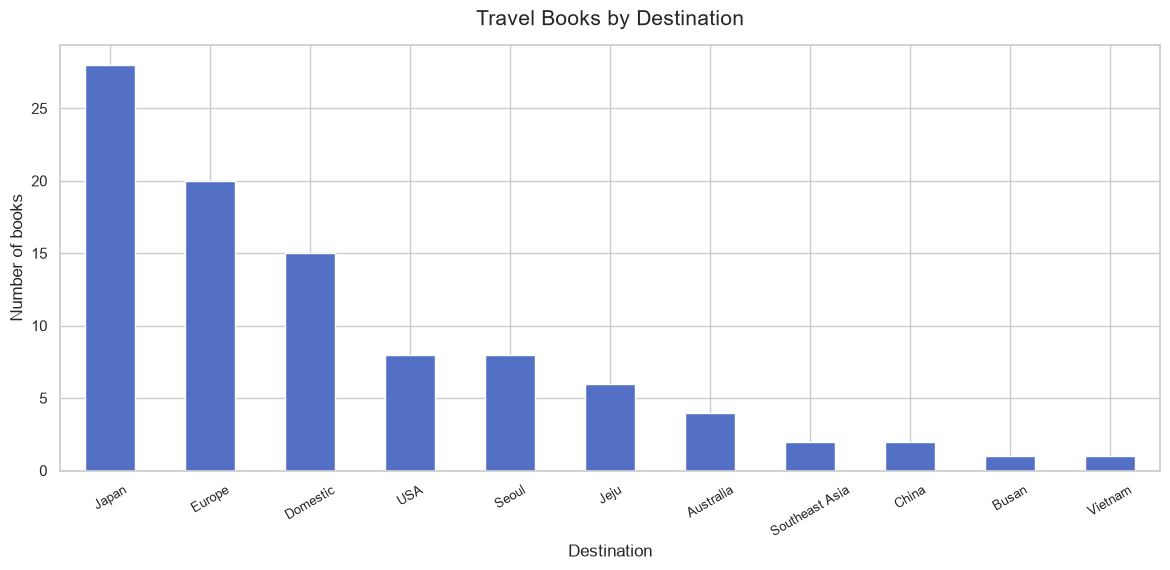

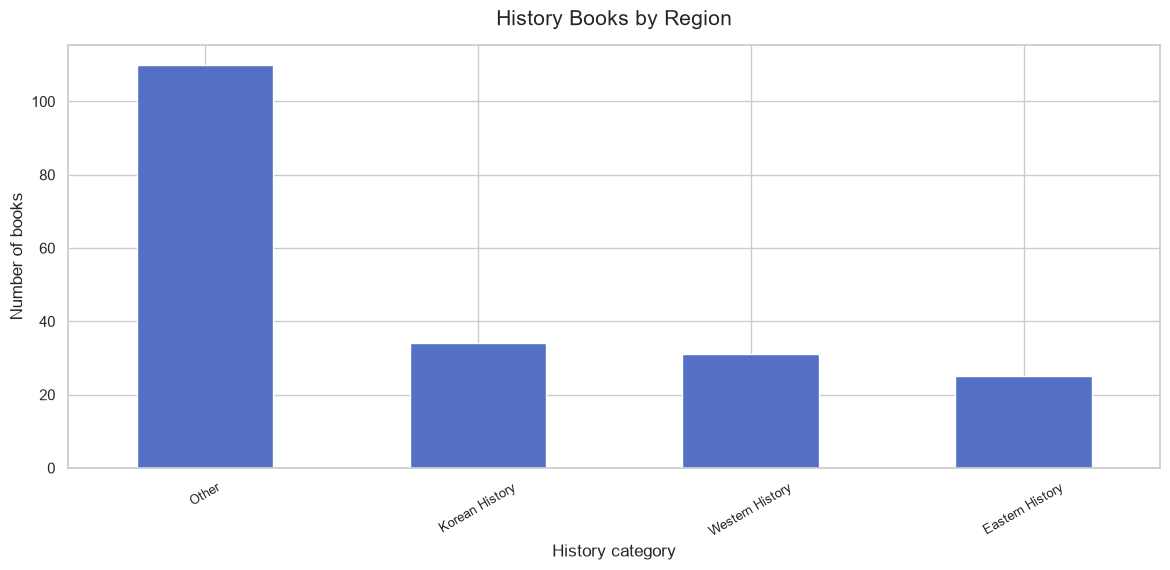

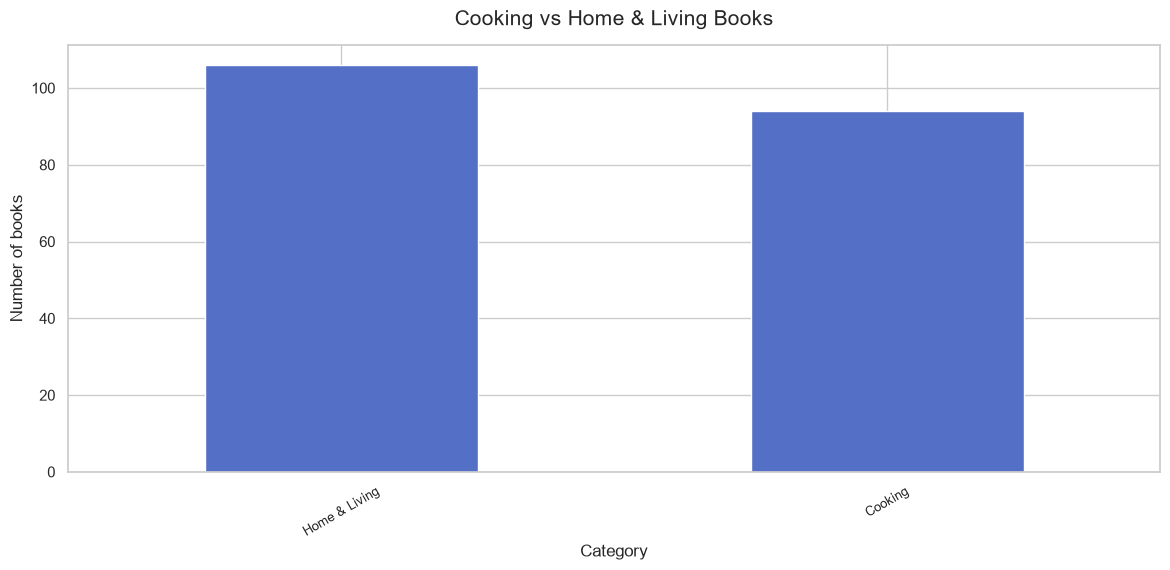

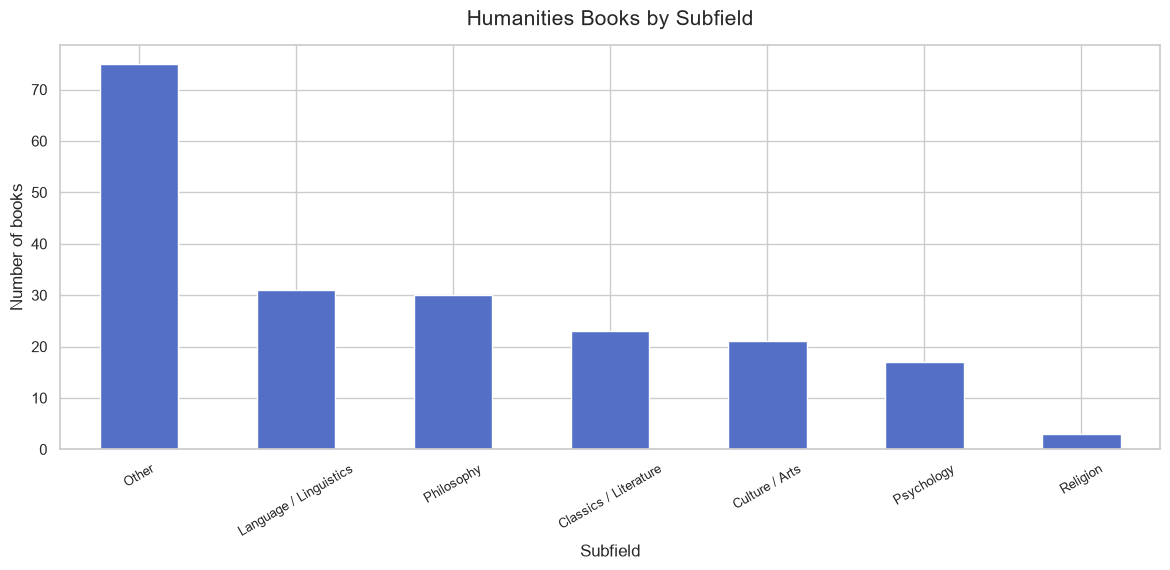

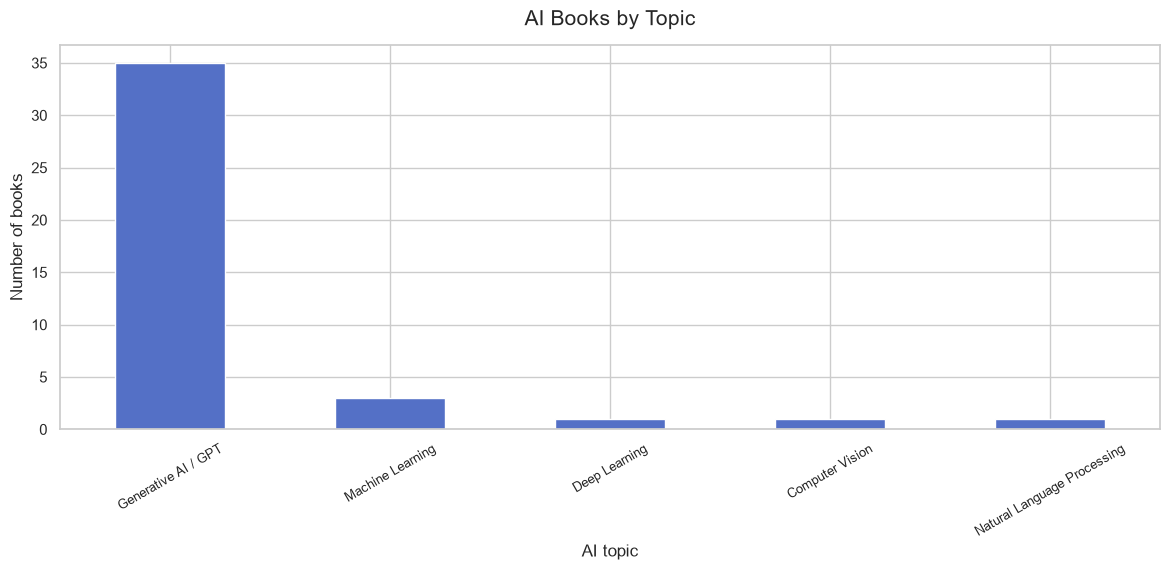

In [83]:
## Font-safe detailed charts
def safe_bar(s,title,xlabel):
    s=s.copy(); s.index=[str(x) for x in s.index]; ax=s.plot.bar(figsize=(12,6),color="#5470C6")
    ax.set_title(title,fontsize=15,pad=14); ax.set_xlabel(xlabel); ax.set_ylabel("Number of books")
    ax.tick_params(axis="x",rotation=30,labelsize=9); plt.tight_layout(pad=1.5); plt.show()
safe_bar(travel_counts[travel_counts.gt(0)].rename(index={"국내":"Domestic","서울":"Seoul","제주":"Jeju","부산":"Busan","일본":"Japan","중국":"China","유럽":"Europe","미국":"USA","동남아":"Southeast Asia","호주":"Australia","대만":"Taiwan","베트남":"Vietnam","태국":"Thailand"}),"Travel Books by Destination","Destination")
safe_bar(history_type.value_counts().rename(index={"한국사":"Korean History","세계사-서양사":"Western History","세계사-동양사":"Eastern History","기타":"Other"}),"History Books by Region","History category")
safe_bar(cooking_type.value_counts().rename(index={"요리":"Cooking","살림":"Home & Living"}),"Cooking vs Home & Living Books","Category")
safe_bar(human_type.value_counts().rename(index={"철학":"Philosophy","심리학":"Psychology","종교":"Religion","고전/문학":"Classics / Literature","언어/언어학":"Language / Linguistics","문화/예술":"Culture / Arts","기타":"Other"}),"Humanities Books by Subfield","Subfield")
safe_bar(ai_counts[ai_counts.gt(0)].rename(index={"생성형 AI/GPT":"Generative AI / GPT","머신러닝":"Machine Learning","딥러닝":"Deep Learning","컴퓨터 비전":"Computer Vision","자연어 처리":"Natural Language Processing"}),"AI Books by Topic","AI topic")
